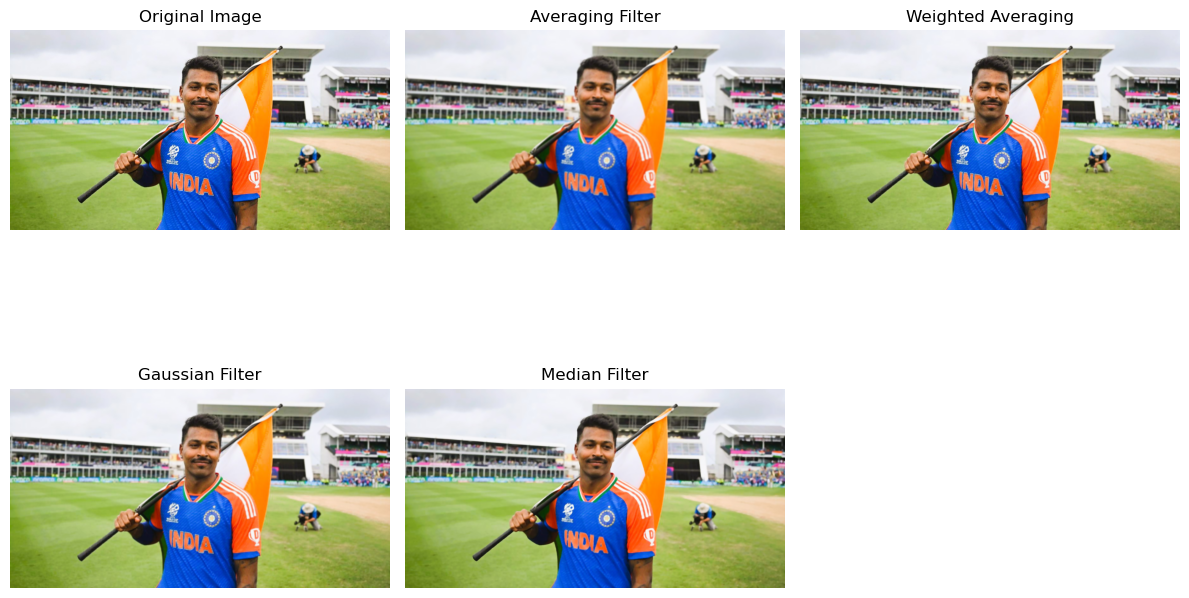

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread("1.jpg")

if image is None:
    raise ValueError("Image not found. Check the image filename and path.")

# Convert BGR to RGB for displaying with Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Averaging Filter
average_blur = cv2.blur(image, (5, 5))

# 2. Weighted Averaging Filter
kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)

kernel = kernel / np.sum(kernel)

weighted_blur = cv2.filter2D(image, -1, kernel)

# 3. Gaussian Filter
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)

# 4. Median Filter
median_blur = cv2.medianBlur(image, 5)

# Convert results from BGR to RGB
average_rgb = cv2.cvtColor(average_blur, cv2.COLOR_BGR2RGB)
weighted_rgb = cv2.cvtColor(weighted_blur, cv2.COLOR_BGR2RGB)
gaussian_rgb = cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB)
median_rgb = cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(average_rgb)
plt.title("Averaging Filter")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(weighted_rgb)
plt.title("Weighted Averaging")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian_rgb)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(median_rgb)
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread("1.jpg")

if image is None:
    raise ValueError("Image not found. Check the file path.")

# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ------------------ 1. Sharpening using Laplacian Linear Kernel ------------------

laplacian_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
], dtype=np.float32)

sharpened_kernel = cv2.filter2D(
    image, 
    -1, 
    laplacian_kernel
)

sharpened_kernel_rgb = cv2.cvtColor(
    sharpened_kernel, 
    cv2.COLOR_BGR2RGB
)

# ------------------ 2. Sharpening using Laplacian Operator ------------------

laplacian = cv2.Laplacian(gray, cv2.CV_64F)

laplacian = cv2.convertScaleAbs(laplacian)

# Convert grayscale Laplacian to 3-channel
laplacian_color = cv2.merge([
    laplacian,
    laplacian,
    laplacian
])

# Add Laplacian details to original image
sharpened_operator = cv2.addWeighted(
    image,
    1.0,
    laplacian_color,
    1.0,
    0
)

sharpened_operator_rgb = cv2.cvtColor(
    sharpened_operator,
    cv2.COLOR_BGR2RGB
)

# ------------------ Display Results ------------------

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sharpened_kernel_rgb)
plt.title("Laplacian Linear Kernel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharpened_operator_rgb)
plt.title("Laplacian Operator")
plt.axis("off")

plt.tight_layout()
plt.show()

NameError: name 'cv2_imshow' is not defined